# Analysing NLP Features
Confirming text aligns with scores issued

#### Load Parquets
1. Raw emotions parquet (anger, disgust, fear, joy, etc.)
2. Unified emotions parquet (+ve, -ve, ≈)

In [1]:
import pandas as pd

In [2]:
raw_nlp = pd.read_parquet("../data/dataset/stock_tweets_sentiment_rawemotion_stanceScore_nomerge.parquet")
unify_nlp = pd.read_parquet("../data/dataset/stock_tweets_sentiment_unifyemotion_stanceScore_nomerge.parquet")

In [3]:
raw_nlp.info()
unify_nlp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106338 entries, 0 to 106337
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype              
---  ------            --------------   -----              
 0   ticker            106338 non-null  object             
 1   text              106338 non-null  object             
 2   created_at        106338 non-null  datetime64[ns, UTC]
 3   user_id           106338 non-null  object             
 4   date              106338 non-null  object             
 5   sentiment         106338 non-null  int64              
 6   emotion_anger     106338 non-null  float64            
 7   emotion_disgust   106338 non-null  float64            
 8   emotion_fear      106338 non-null  float64            
 9   emotion_joy       106338 non-null  float64            
 10  emotion_neutral   106338 non-null  float64            
 11  emotion_sadness   106338 non-null  float64            
 12  emotion_surprize  106338 non-null  float64  

### Sample Spot Check

In [4]:
pd.set_option("display.max_colwidth", None)

import random

sample_size = random.randint(50, 100)

def review_sample(df, cols, label):
    sample = df.sample(n=sample_size, random_state=42).copy()
    print(f"\n=== {label} (n={sample_size}) ===")
    display(sample[cols])
    return sample

raw_cols = [
    "ticker", "text", "sentiment",
    "emotion_anger", "emotion_disgust", "emotion_fear",
    "emotion_joy", "emotion_neutral", "emotion_sadness",
    "emotion_surprize", "stance_label", "stance_score"
]
unify_cols = [
    "ticker", "text", "sentiment",
    "positive_emotion", "negative_emotion", "uncertainty_emotion",
    "stance_label", "stance_score"
]

raw_sample = review_sample(raw_nlp, raw_cols, "Raw emotions")
unify_sample = review_sample(unify_nlp, unify_cols, "Unified emotions")


=== Raw emotions (n=72) ===


,ticker,text,sentiment,emotion_anger,emotion_disgust,emotion_fear,emotion_joy,emotion_neutral,emotion_sadness,emotion_surprize,stance_label,stance_score
52117,FB,are you putting your money in dnkn al life goto,1,0.670027,0.153461,0.054237,0.051480,0.035466,0.028790,0.006538,Positive,0.826481
89214,PFE,press reporting interested in buying azn would certainly get into immunooncology will be interesting to …,3,0.823238,0.114829,0.033614,0.009037,0.008282,0.008008,0.002992,Positive,0.998524
73475,JPM,tampa event tonight p m et fdic bank closers visit xlf wfc ms met gs c bac axp spy dia qqq dxf,5,0.342155,0.294037,0.286387,0.063986,0.009914,0.002975,0.000546,Positive,0.994146
11181,AAPL,newsxom newssdrl newssdrl toptickertweets spy tza tsla ll twtr sdrl iaci rig xom sent …,1,0.603495,0.279451,0.051712,0.040406,0.011639,0.011402,0.001895,Positive,0.995139
51043,FB,stifel nicolaus deutsche bank and merrill lynch reiterated a buy,1,0.492071,0.362203,0.063605,0.036789,0.023656,0.019687,0.001991,Positive,0.998377
...,...,...,...,...,...,...,...,...,...,...,...,...
3580,AAPL,tbt remember when tim cook was the worst ceo ever that was cool,1,0.574244,0.206015,0.094803,0.066567,0.032798,0.013813,0.011760,Negative,0.822448
63950,GOOG,amzn in talks to buy grpn for b fb should have bought them instead of oculus will step in,1,0.548114,0.248833,0.166468,0.022855,0.007194,0.004557,0.001978,Positive,0.998448
83741,MSFT,our pick on ppch is up for our subscribers big news xlf f fn,5,0.774734,0.137120,0.058185,0.011869,0.011702,0.005545,0.000846,Positive,0.992959
46081,D,a ap rocky l,5,0.674273,0.102672,0.069941,0.061889,0.039184,0.037938,0.014103,Positive,0.708216



=== Unified emotions (n=72) ===


,ticker,text,sentiment,positive_emotion,negative_emotion,uncertainty_emotion,stance_label,stance_score
52117,FB,are you putting your money in dnkn al life goto,1,0.051480,0.852278,0.060775,Positive,0.826481
89214,PFE,press reporting interested in buying azn would certainly get into immunooncology will be interesting to …,3,0.009037,0.946075,0.036606,Positive,0.998524
73475,JPM,tampa event tonight p m et fdic bank closers visit xlf wfc ms met gs c bac axp spy dia qqq dxf,5,0.063986,0.639167,0.286933,Positive,0.994146
11181,AAPL,newsxom newssdrl newssdrl toptickertweets spy tza tsla ll twtr sdrl iaci rig xom sent …,1,0.040406,0.894348,0.053607,Positive,0.995139
51043,FB,stifel nicolaus deutsche bank and merrill lynch reiterated a buy,1,0.036789,0.873960,0.065596,Positive,0.998377
...,...,...,...,...,...,...,...,...
3580,AAPL,tbt remember when tim cook was the worst ceo ever that was cool,1,0.066567,0.794072,0.106563,Negative,0.822448
63950,GOOG,amzn in talks to buy grpn for b fb should have bought them instead of oculus will step in,1,0.022855,0.801504,0.168446,Positive,0.998448
83741,MSFT,our pick on ppch is up for our subscribers big news xlf f fn,5,0.011869,0.917398,0.059030,Positive,0.992959
46081,D,a ap rocky l,5,0.061889,0.814883,0.084045,Positive,0.708216


# Sanity Distribution
Looking out for extreme skews

Raw stance_label distribution:
 stance_label
Positive    0.782956
Negative    0.217044
Name: proportion, dtype: float64
Unified stance_label distribution:
 stance_label
Positive    0.782956
Negative    0.217044
Name: proportion, dtype: float64
Raw out-of-bounds counts:
 emotion_anger       0
emotion_disgust     0
emotion_fear        0
emotion_joy         0
emotion_neutral     0
emotion_sadness     0
emotion_surprize    0
stance_score        0
dtype: int64
Unified out-of-bounds counts:
 positive_emotion       0
negative_emotion       0
uncertainty_emotion    0
stance_score           0
dtype: int64


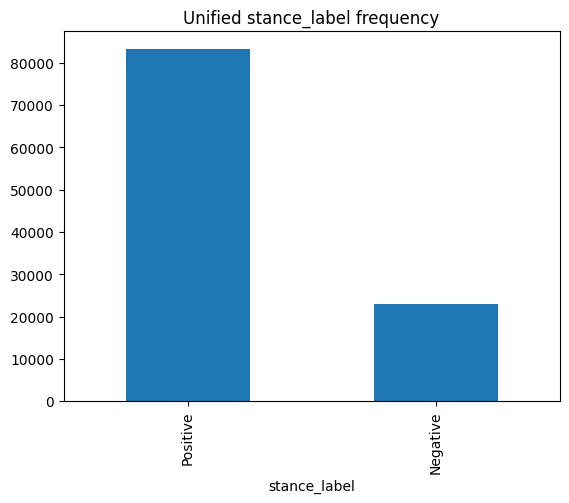

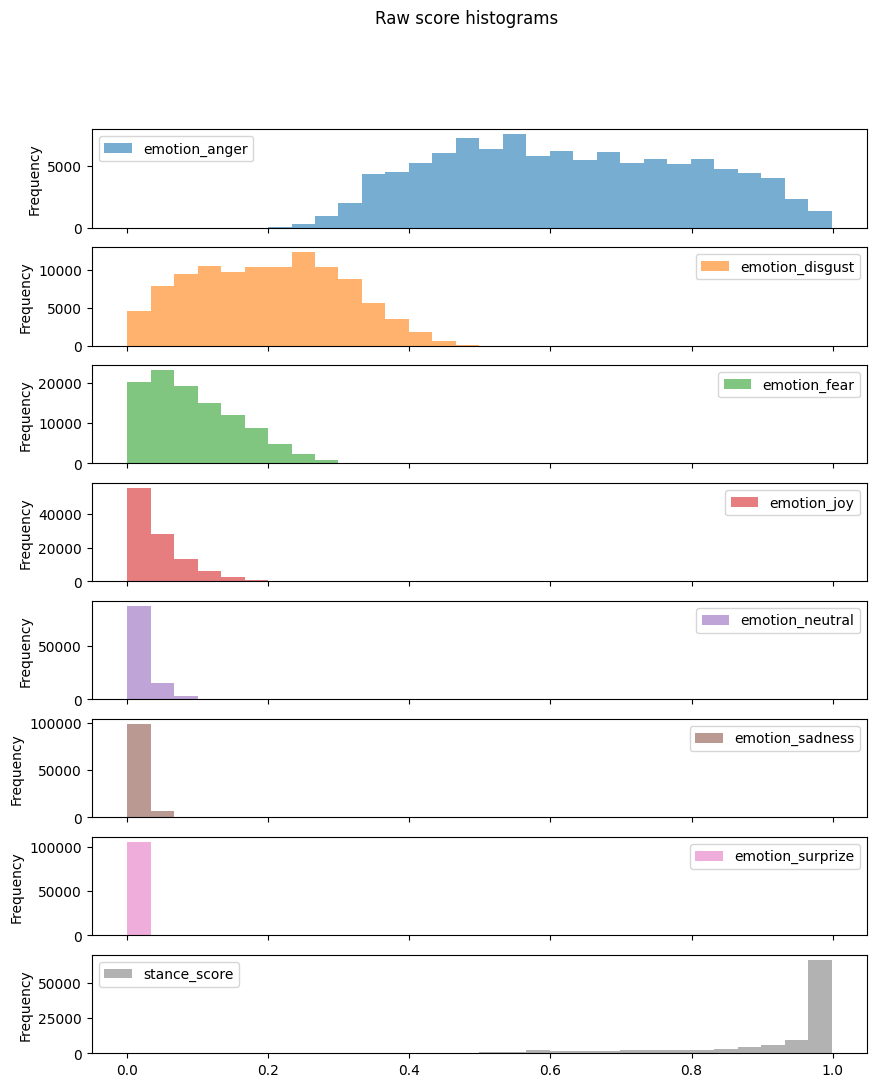

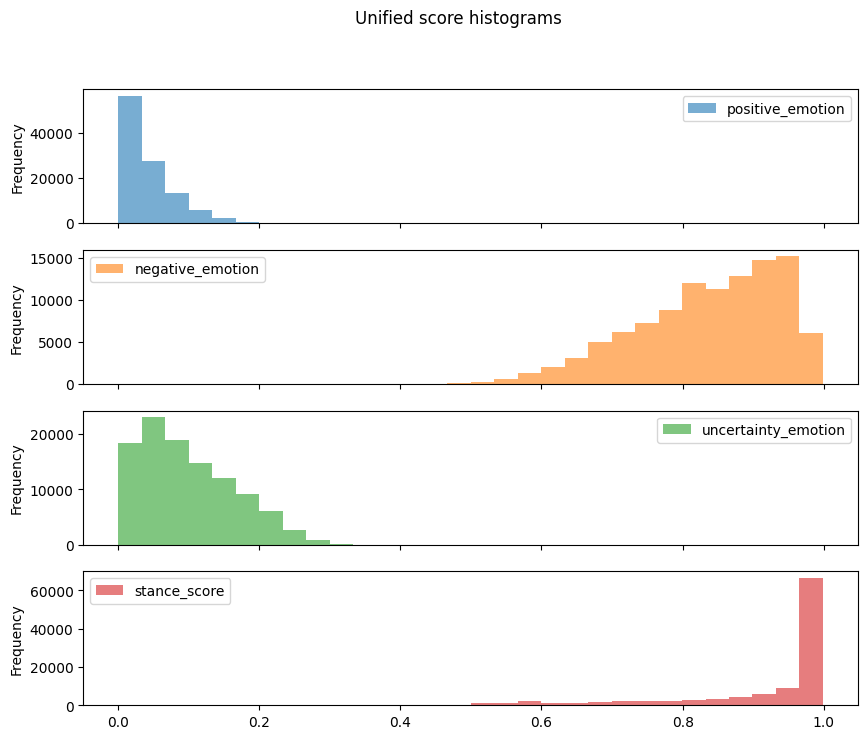

In [5]:
# Label frequency plots
raw_nlp["stance_label"].value_counts().plot(kind="bar", title="Raw stance_label frequency")
unify_nlp["stance_label"].value_counts().plot(kind="bar", title="Unified stance_label frequency")

# Score histograms
raw_score_cols = [
    "emotion_anger", "emotion_disgust", "emotion_fear", "emotion_joy",
    "emotion_neutral", "emotion_sadness", "emotion_surprize", "stance_score"
]
unify_score_cols = ["positive_emotion", "negative_emotion", "uncertainty_emotion", "stance_score"]

raw_nlp[raw_score_cols].plot(kind="hist", bins=30, alpha=0.6, subplots=True, figsize=(10, 12), title="Raw score histograms")
unify_nlp[unify_score_cols].plot(kind="hist", bins=30, alpha=0.6, subplots=True, figsize=(10, 8), title="Unified score histograms")

# Impossible values check (outside [0, 1])
raw_out_of_bounds = (raw_nlp[raw_score_cols] < 0) | (raw_nlp[raw_score_cols] > 1)
unify_out_of_bounds = (unify_nlp[unify_score_cols] < 0) | (unify_nlp[unify_score_cols] > 1)

raw_nlp['stance_label'].value_counts(normalize=True)
unify_nlp['stance_label'].value_counts(normalize=True)

print("Raw stance_label distribution:\n", raw_nlp['stance_label'].value_counts(normalize=True))
print("Unified stance_label distribution:\n", unify_nlp['stance_label'].value_counts(normalize=True))

print("Raw out-of-bounds counts:\n", raw_out_of_bounds.sum())
print("Unified out-of-bounds counts:\n", unify_out_of_bounds.sum())



In [6]:
raw_negative = raw_nlp[raw_nlp["stance_label"].str.lower() == "negative"]
unify_negative = unify_nlp[unify_nlp["stance_label"].str.lower() == "negative"]

display(raw_negative[raw_cols])
display(unify_negative[unify_cols])

,ticker,text,sentiment,emotion_anger,emotion_disgust,emotion_fear,emotion_joy,emotion_neutral,emotion_sadness,emotion_surprize,stance_label,stance_score
6,AAPL,apple screwed up big time amzn,1,0.375377,0.305168,0.160723,0.127933,0.013397,0.012308,0.005095,Negative,0.949585
16,AAPL,premarket apple downgraded on margin concerns stocks to start > stock stocks stockaction,1,0.783976,0.066338,0.056245,0.046800,0.031082,0.013646,0.001912,Negative,0.985842
20,AAPL,this weeks puts are already up a dollar today,1,0.527093,0.387060,0.062848,0.009667,0.007006,0.003632,0.002693,Negative,0.994979
21,AAPL,apple gained in vs s ps but dont cry for investors at least not the long term ones,3,0.959321,0.020614,0.009928,0.007494,0.001241,0.000717,0.000685,Negative,0.907284
25,AAPL,us stockswall st kicks off new year on lower note,1,0.547740,0.214618,0.169101,0.030242,0.018407,0.017878,0.002015,Negative,0.880181
...,...,...,...,...,...,...,...,...,...,...,...,...
106313,XOM,owoo recent news updated monday december pm sh foxa uvxy,1,0.452300,0.367421,0.089010,0.085241,0.003116,0.001785,0.001126,Negative,0.525225
106326,XOM,rgse real goods solar company info rgse uvxy tna rgse share investing,5,0.652781,0.131397,0.126271,0.053193,0.019818,0.013188,0.003352,Negative,0.846123
106327,XOM,wtic spot to regain support or test resistance uso cvx rig spy oil oih oil charts,1,0.501846,0.326279,0.054508,0.046299,0.043633,0.023960,0.003474,Negative,0.932283
106331,XOM,divest from stopcommoncore optout because children are not exxonproducts boycottexxon https …,1,0.763934,0.115369,0.071567,0.021422,0.012145,0.009175,0.006386,Negative,0.949051


,ticker,text,sentiment,positive_emotion,negative_emotion,uncertainty_emotion,stance_label,stance_score
6,AAPL,apple screwed up big time amzn,1,0.127933,0.692853,0.165817,Negative,0.949585
16,AAPL,premarket apple downgraded on margin concerns stocks to start > stock stocks stockaction,1,0.046800,0.863961,0.058157,Negative,0.985842
20,AAPL,this weeks puts are already up a dollar today,1,0.009667,0.917785,0.065542,Negative,0.994979
21,AAPL,apple gained in vs s ps but dont cry for investors at least not the long term ones,3,0.007494,0.980651,0.010613,Negative,0.907284
25,AAPL,us stockswall st kicks off new year on lower note,1,0.030242,0.780235,0.171116,Negative,0.880181
...,...,...,...,...,...,...,...,...
106313,XOM,owoo recent news updated monday december pm sh foxa uvxy,1,0.085241,0.821506,0.090136,Negative,0.525225
106326,XOM,rgse real goods solar company info rgse uvxy tna rgse share investing,5,0.053193,0.797366,0.129623,Negative,0.846123
106327,XOM,wtic spot to regain support or test resistance uso cvx rig spy oil oih oil charts,1,0.046299,0.852085,0.057983,Negative,0.932283
106331,XOM,divest from stopcommoncore optout because children are not exxonproducts boycottexxon https …,1,0.021422,0.888479,0.077954,Negative,0.949051


In [7]:
raw_positive = raw_nlp[raw_nlp["stance_label"].str.lower() == "positive"]
unify_positive = unify_nlp[unify_nlp["stance_label"].str.lower() == "positive"]

display(raw_positive[raw_cols])
display(unify_positive[unify_cols])

,ticker,text,sentiment,emotion_anger,emotion_disgust,emotion_fear,emotion_joy,emotion_neutral,emotion_sadness,emotion_surprize,stance_label,stance_score
0,AAPL,summary of yesterdays webcast featuring wynn goog lgf tradereducation options hedgingstrategies,4,0.677257,0.148463,0.143604,0.021908,0.004223,0.003426,0.001120,Positive,0.742110
1,AAPL,summary of yesterdays webcast featuring wynn goog lgf tradereducation options hedgingstrategies,4,0.677257,0.148463,0.143604,0.021908,0.004223,0.003426,0.001120,Positive,0.742110
2,AAPL,iphone users are more intelligent than samsung blackberry and htc owners bbry,5,0.651749,0.290809,0.032565,0.017082,0.004068,0.001948,0.001778,Positive,0.998410
3,AAPL,summary of yesterdays webcast featuring wynn goog lgf tradereducation options hedgingstrategies,4,0.677257,0.148463,0.143604,0.021908,0.004223,0.003426,0.001120,Positive,0.742110
4,AAPL,summary of yesterdays webcast featuring wynn goog lgf tradereducation options hedgingstrategies,4,0.677257,0.148463,0.143604,0.021908,0.004223,0.003426,0.001120,Positive,0.742110
...,...,...,...,...,...,...,...,...,...,...,...,...
106332,XOM,mcd mcdonalds corp e p s mcd cslt expe mcd finance stocks,3,0.444075,0.302551,0.118045,0.097707,0.021382,0.014788,0.001452,Positive,0.915546
106333,XOM,t active morning movers at t nyse t exxon mobil …,5,0.793153,0.089309,0.077659,0.018933,0.011689,0.007353,0.001905,Positive,0.803462
106335,XOM,zsl stock forum zsl gold uslv zsl investing nasdaq,5,0.488881,0.242657,0.201586,0.045692,0.012491,0.007334,0.001360,Positive,0.997038
106336,XOM,nptn recent news updated tuesday december pm gdxj fb uup,1,0.456476,0.355527,0.112046,0.067945,0.003791,0.003206,0.001009,Positive,0.997328


,ticker,text,sentiment,positive_emotion,negative_emotion,uncertainty_emotion,stance_label,stance_score
0,AAPL,summary of yesterdays webcast featuring wynn goog lgf tradereducation options hedgingstrategies,4,0.021908,0.829146,0.144724,Positive,0.742110
1,AAPL,summary of yesterdays webcast featuring wynn goog lgf tradereducation options hedgingstrategies,4,0.021908,0.829146,0.144724,Positive,0.742110
2,AAPL,iphone users are more intelligent than samsung blackberry and htc owners bbry,5,0.017082,0.944506,0.034343,Positive,0.998410
3,AAPL,summary of yesterdays webcast featuring wynn goog lgf tradereducation options hedgingstrategies,4,0.021908,0.829146,0.144724,Positive,0.742110
4,AAPL,summary of yesterdays webcast featuring wynn goog lgf tradereducation options hedgingstrategies,4,0.021908,0.829146,0.144724,Positive,0.742110
...,...,...,...,...,...,...,...,...
106332,XOM,mcd mcdonalds corp e p s mcd cslt expe mcd finance stocks,3,0.097707,0.761414,0.119497,Positive,0.915546
106333,XOM,t active morning movers at t nyse t exxon mobil …,5,0.018933,0.889814,0.079564,Positive,0.803462
106335,XOM,zsl stock forum zsl gold uslv zsl investing nasdaq,5,0.045692,0.738872,0.202946,Positive,0.997038
106336,XOM,nptn recent news updated tuesday december pm gdxj fb uup,1,0.067945,0.815209,0.113054,Positive,0.997328
